# R² threshold comparison across Emmental configurations

In [1]:
import os
import r2

## Post joint mode training

For each **configuration** (experiment folder), load `train_r2_scores.csv` and `test_r2_scores.csv` from every `run_*` directory.

**Per run**, compute the **fraction of genes** (one R² per gene in the CSV) with \(R^2 > 0.01\) or \(R^2 > 0.1\), for train and test separately — not a threshold on the run’s average R² across genes.

**Batching:** runs are ordered by run index and grouped in batches of up to N. For each batch, **average each gene’s R² across those runs**, then compute each proportion as the **fraction of genes** whose *batch-averaged* R² exceeds threshold (not the average of the per-run gene fractions). So 100 refits, batch size 10 → **10** batch-level values; 5 refits, batch size 10 → **1** batch.

- **`experiments`**: list of dictionaries with the following keys:
    - `joint_root`: joint emmental training output directory path (with run subdirectories)
    - `runs`: list of refit runs (names of subdirectories)
    - `label` (optional): label for plots; defualts to basename of `joint_root`


#### Define set of configurations to compare

In [6]:
N = 10
experiments_joint = []

PREFIX = "train_common01"
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS_myout"

for config in ["full"]: #, "no_rhog", "no_wg", "no_wg_rhog"]:
    experiments_joint.extend([{"joint_root": os.path.join(EXPERIMENTS_ROOT, PREFIX, config, "joint"), "runs": [f"run_{i}" for i in range(1, N+1) if f"run_{i}" in os.listdir(os.path.join(EXPERIMENTS_ROOT, PREFIX, config, "joint"))], "label": f'common_{config}'}])

EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS_myout"
configs = [{'config': f"{PREFIX}_normG_fixed", 'label': 'common_full_normG'},
    {'config': f"{PREFIX}_full_collapse", 'label': 'common_full_collapse'},
    {'config': f"{PREFIX}_normG_collapse", 'label': 'common_full_normG_collapse'},
    {'config': f"{PREFIX}_normG_collapse_initwg0", 'label': 'common_full_normG_collapse_initwg0'},
    {'config': f"{PREFIX}_normG_collapse_Tinit_data_quantile", 'label': 'common_full_normG_collapse_Tinit_data_quantile'},
    {'config': f"{PREFIX}_normG_collapse_wg1", 'label': 'common_full_normG_collapse_wg1'},
    {'config': f"{PREFIX}_normG_collapse_Tprior_1_1", 'label': 'common_full_normG_collapse_Tprior_1_1'},
    {'config': f"{PREFIX}_normG_collapse_Tprior_2_8", 'label': 'common_full_normG_collapse_Tprior_2_8'},
    ]

for config in configs:
    experiments_joint.extend([{"joint_root": os.path.join(EXPERIMENTS_ROOT, config['config'], "joint"), "runs": [f"run_{i}" for i in range(1, N+1) if f"run_{i}" in os.listdir(os.path.join(EXPERIMENTS_ROOT, config['config'], "joint"))], "label": config['label']}])

BATCH_SIZE = 10

In [7]:
N=5 
#experiments_joint = []
EXPERIMENTS_ROOT = "/gpfs/commons/home/vmazeeva/firvTWAS_myout/train_common01_normG_collapse_variants"

VARIANTS = [
    # Structural (8)
    "full",
    "no_wg",
    "no_rhog",
    "no_wg_rhog",
    "noT",
    "no_wg_noT",
    "no_rhog_noT",
    "no_wg_rhog_noT",
    # T prior/init on full structure (5)
    "T_default",
    "Tprior_2_8",
    "Tprior_1_1",
    "Tinit_prior_mode",
    "Tinit_data_q25",
    # T variants on no_wg (3)
    "T_no_wg_prior_2_8",
    "T_no_wg_prior_1_1",
    "T_no_wg_init_data_q25",
    # T variants on no_rhog (3)
    "T_no_rhog_prior_2_8",
    "T_no_rhog_prior_1_1",
    "T_no_rhog_init_data_q25",
    # T variants on no_wg_rhog (3)
    "T_no_wg_rhog_prior_2_8",
    "T_no_wg_rhog_prior_1_1",
    "T_no_wg_rhog_init_data_q25",
]

for var in VARIANTS:
    experiments_joint.extend([{"joint_root": os.path.join(EXPERIMENTS_ROOT, var, "joint"), "runs": [f"run_{i}" for i in range(1, N+1) if f"run_{i}" in os.listdir(os.path.join(EXPERIMENTS_ROOT, var, "joint"))], "label": var}])

BATCH_SIZE = N


#### Prep data

In [8]:
batch_df = r2.get_r2_stats_batched_joint(experiments_joint, BATCH_SIZE)
batch_df

,exp_label,batch_id,prop_train_gt_001,prop_train_gt_01,prop_test_gt_001,prop_test_gt_01,mean_r2_train,mean_r2_test
0,T_default,0,1.000,0.915,1.000,0.975,0.233661,0.254222
1,T_no_rhog_init_data_q25,0,1.000,0.900,0.995,0.975,0.219035,0.248327
2,T_no_rhog_prior_1_1,0,1.000,0.790,0.995,0.945,0.190973,0.219864
3,T_no_rhog_prior_2_8,0,1.000,0.860,0.995,0.970,0.211986,0.243737
4,T_no_wg_init_data_q25,0,1.000,0.915,1.000,0.975,0.228477,0.249894
5,T_no_wg_prior_1_1,0,0.960,0.165,0.975,0.200,0.066004,0.074259
6,T_no_wg_prior_2_8,0,1.000,0.775,0.995,0.930,0.179687,0.208204
7,T_no_wg_rhog_init_data_q25,0,1.000,0.865,0.995,0.960,0.208618,0.241416
8,T_no_wg_rhog_prior_1_1,0,0.960,0.120,0.980,0.155,0.058051,0.064630
9,T_no_wg_rhog_prior_2_8,0,1.000,0.775,0.995,0.925,0.180201,0.208382


#### Plots




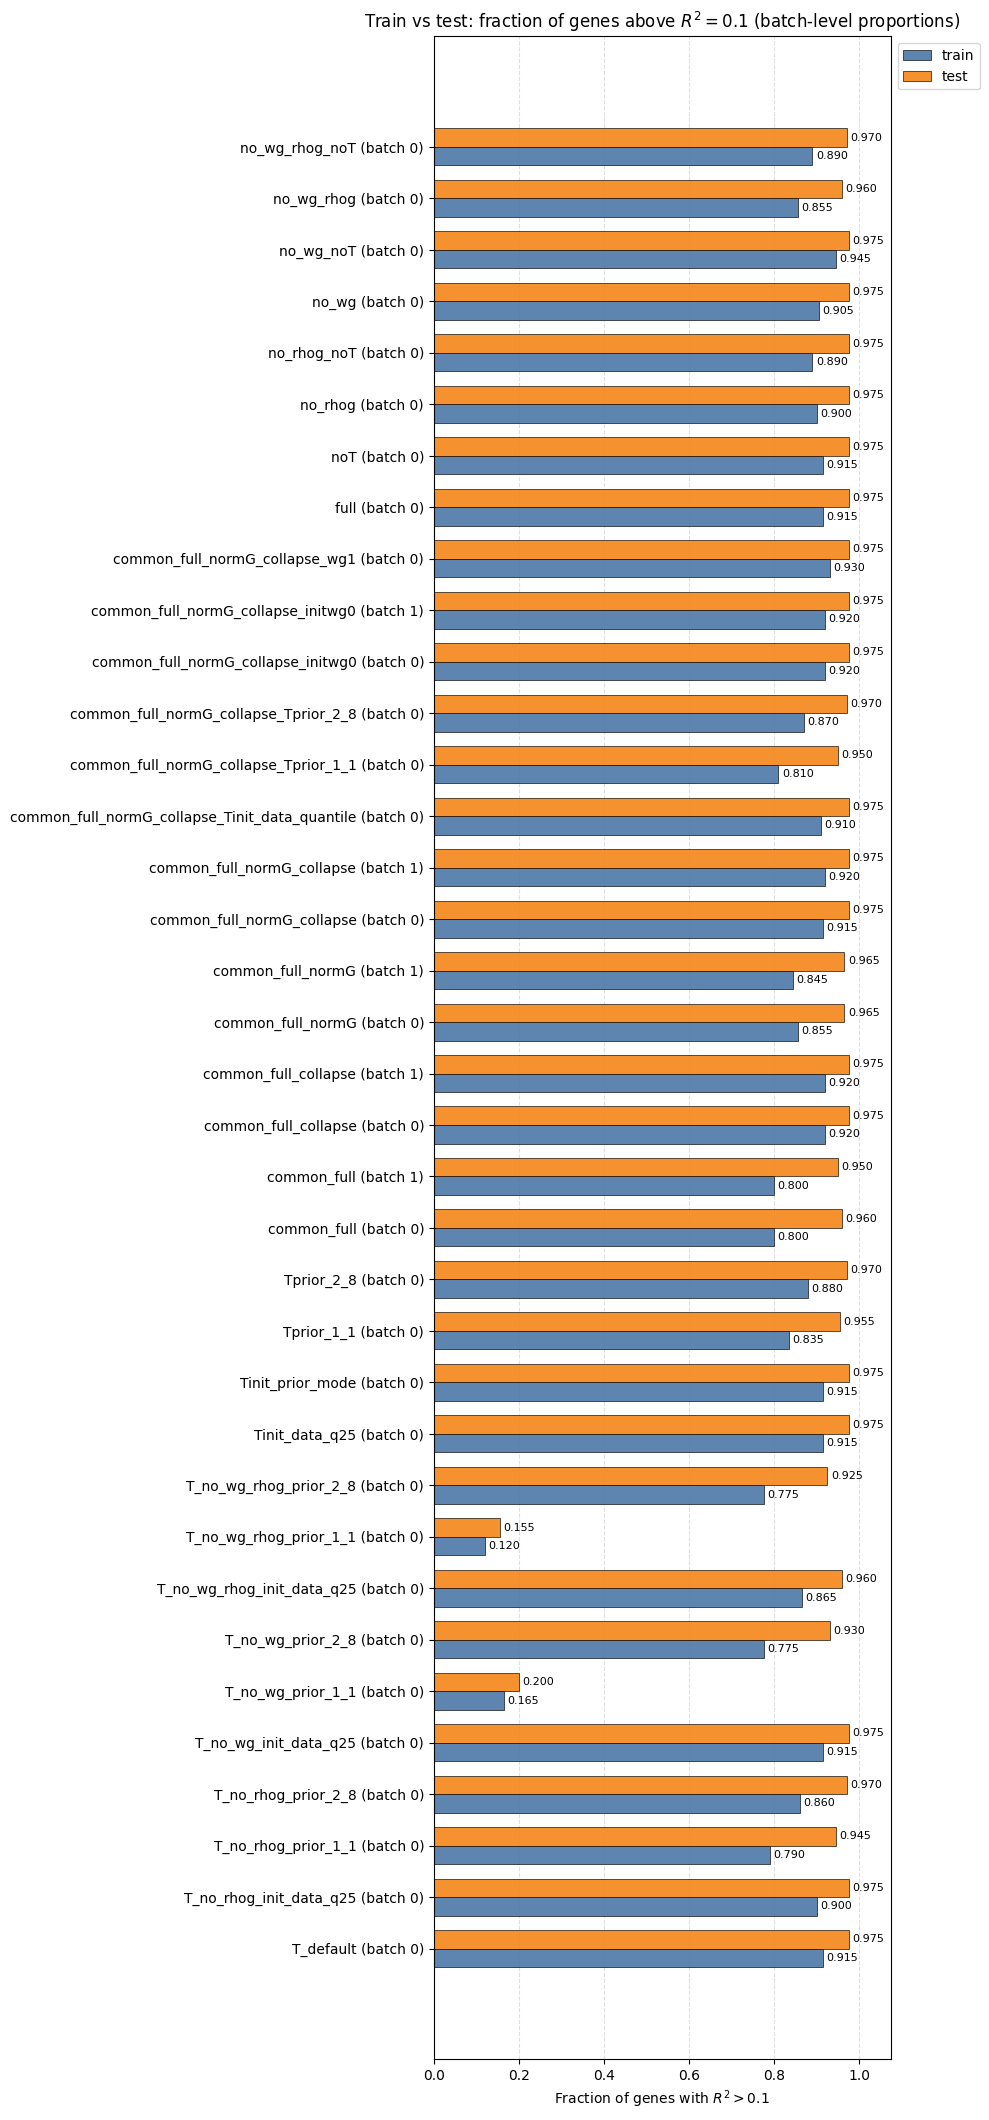

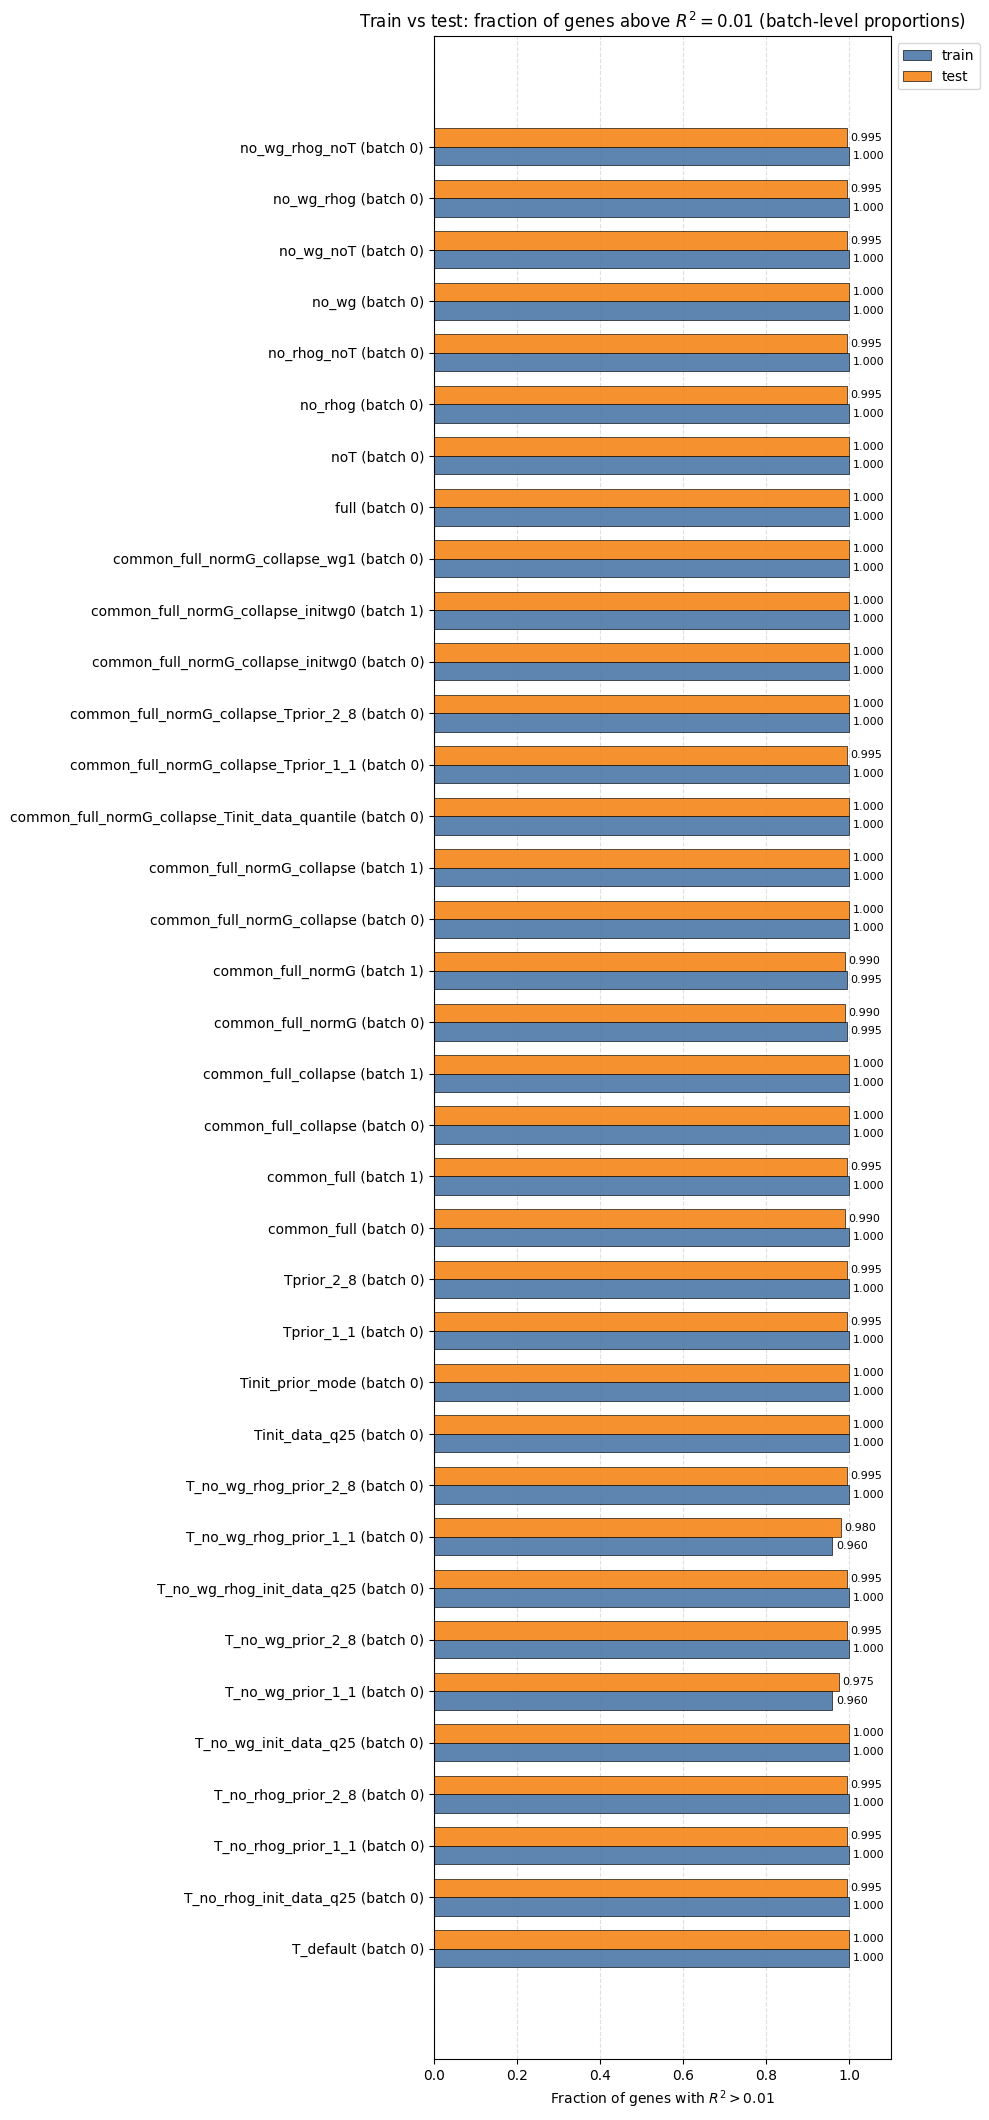

In [9]:
r2.plot_train_test_bars(
    batch_df
)
r2.plot_train_test_bars(
    batch_df,
    thresh=0.01,
)

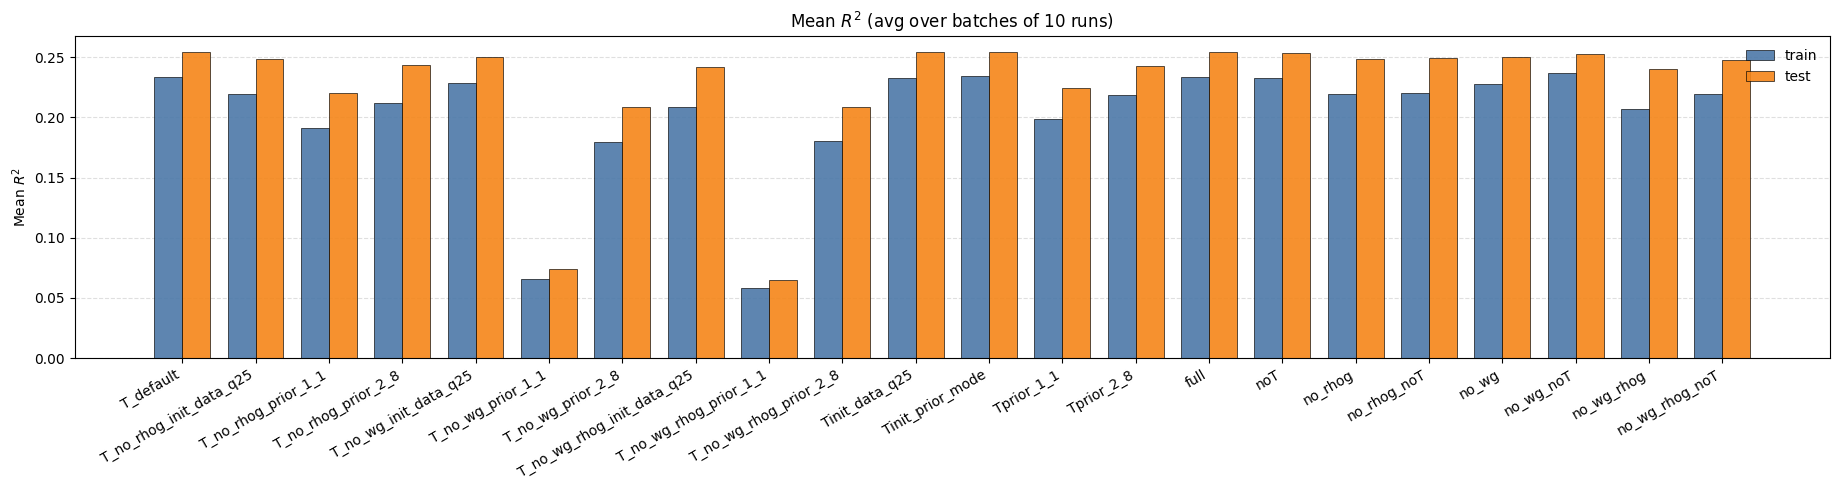

In [86]:
r2.plot_mean_r2_per_configuration(batch_df)


## Post per-gene mode

- **Single refit** (only ``chr1``…``chr22`` under ``pergene/``): all chromosomes are merged into **one batch** (`batch_id=0`).
- **Refit matches joint** (``pergene/run_1`` …): each run is loaded (merging ``run_N/chr*`` when needed) and batched in groups of `BATCH_SIZE` like joint.

#### Define set of configurations to compare

In [10]:
experiments_pergene = []
for exp in experiments_joint: 
    pergene_root = exp["joint_root"].replace("joint", "pergene")
    experiments_pergene.append({
        "label": exp["label"],
        "pergene_root": pergene_root,
    })


#### Prep data

In [11]:
batch_df_pergene = r2.get_r2_stats_batched_pergene(experiments_pergene)
batch_df_pergene


skip no_wg_rhog: no R² data
skip no_rhog_noT: no R² data
skip no_wg_rhog_noT: no R² data
skip T_default: no R² data
skip Tinit_data_q25: no R² data
skip T_no_wg_rhog_prior_2_8: no R² data
skip T_no_wg_rhog_prior_1_1: no R² data
skip T_no_wg_rhog_init_data_q25: no R² data


,exp_label,batch_id,prop_train_gt_001,prop_train_gt_01,prop_test_gt_001,prop_test_gt_01,mean_r2_train,mean_r2_test
0,T_no_rhog_init_data_q25,0,0.993711,0.105240,0.209864,0.020838,0.060120,-0.007047
1,T_no_rhog_prior_1_1,0,0.821085,0.017818,0.189149,0.018619,0.024475,0.000100
2,T_no_rhog_prior_2_8,0,0.984772,0.054686,0.202096,0.020284,0.047700,-0.004462
3,T_no_wg_init_data_q25,0,0.963009,0.047164,0.218742,0.021147,0.042499,-0.000094
4,T_no_wg_prior_1_1,0,0.001418,0.000062,0.001541,0.000185,0.000056,0.000074
5,T_no_wg_prior_2_8,0,0.366954,0.011159,0.179162,0.015043,0.012930,0.004515
6,Tinit_prior_mode,0,0.852255,0.036001,0.243807,0.020852,0.031434,0.006920
7,Tprior_1_1,0,0.880025,0.021455,0.193773,0.019297,0.028122,-0.000490
8,Tprior_2_8,0,0.889334,0.025401,0.239026,0.020530,0.029400,0.006669
9,common_full,0,0.472873,0.021085,0.211961,0.020345,0.017716,0.008488


#### Plots

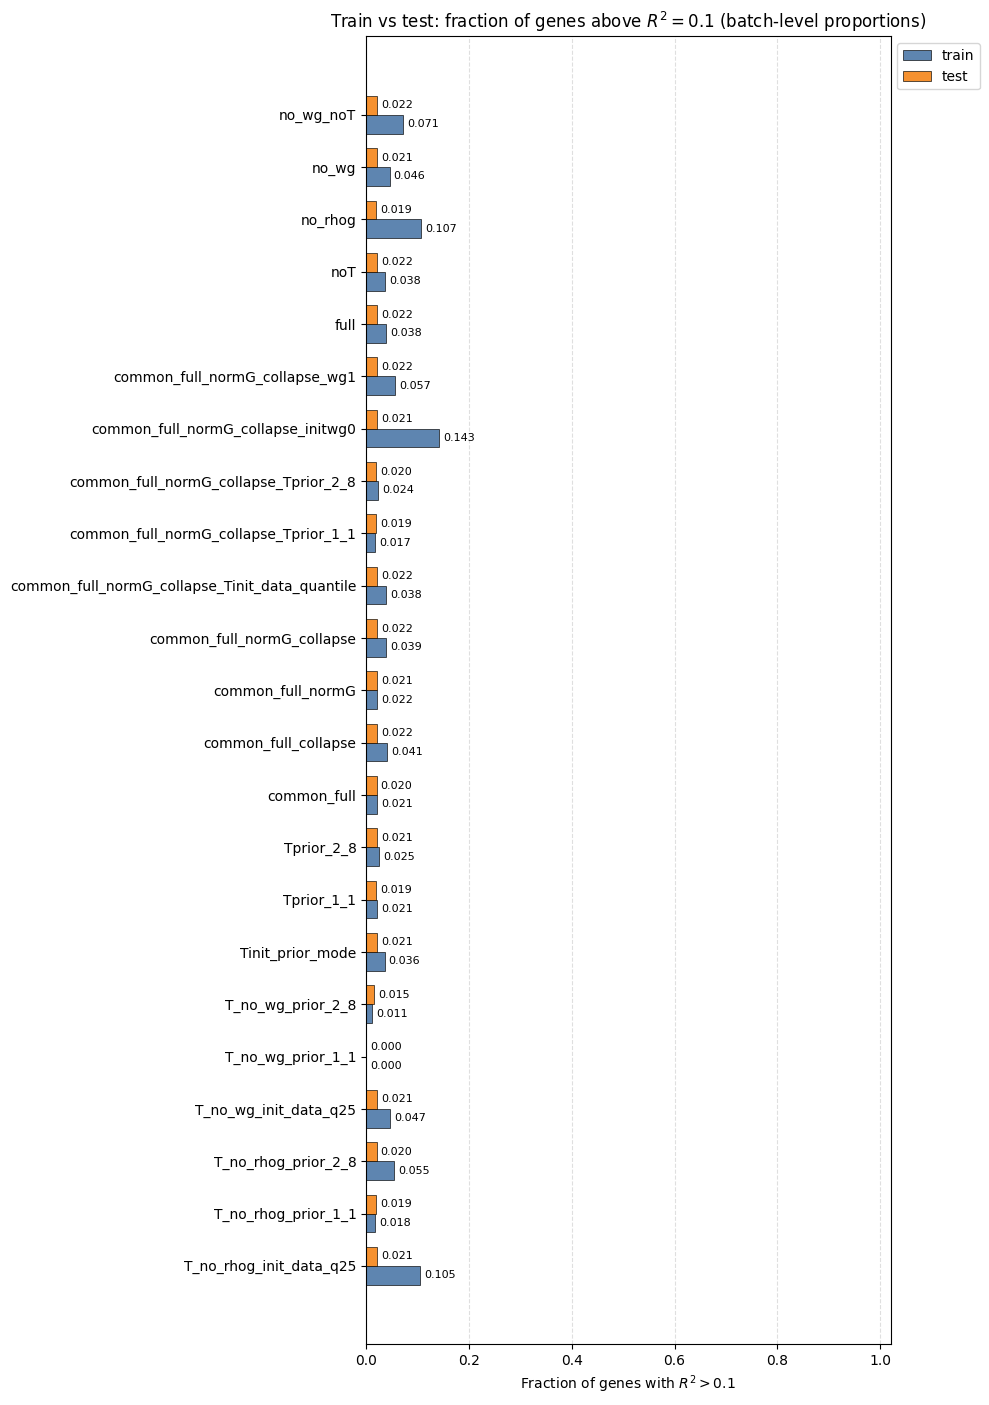

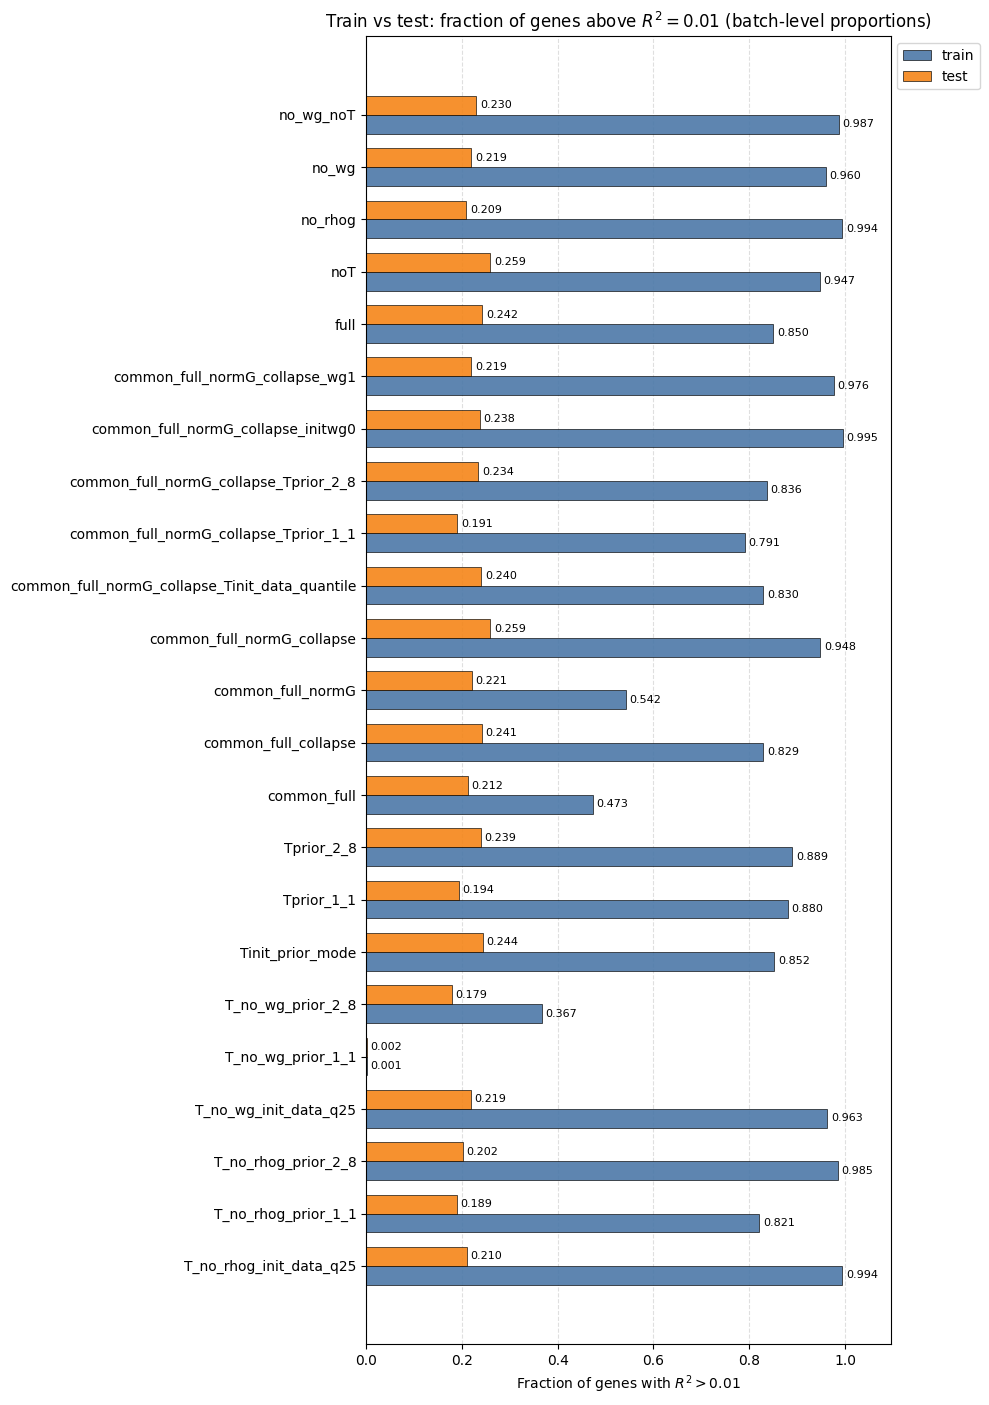

In [12]:
r2.plot_train_test_bars(batch_df_pergene, thresh=0.1)
r2.plot_train_test_bars(batch_df_pergene, thresh=0.01)



skip no_wg_rhog: no R² data
skip no_rhog_noT: no R² data
skip no_wg_rhog_noT: no R² data
skip T_default: no R² data
skip Tinit_data_q25: no R² data
skip T_no_wg_rhog_prior_2_8: no R² data
skip T_no_wg_rhog_prior_1_1: no R² data
skip T_no_wg_rhog_init_data_q25: no R² data


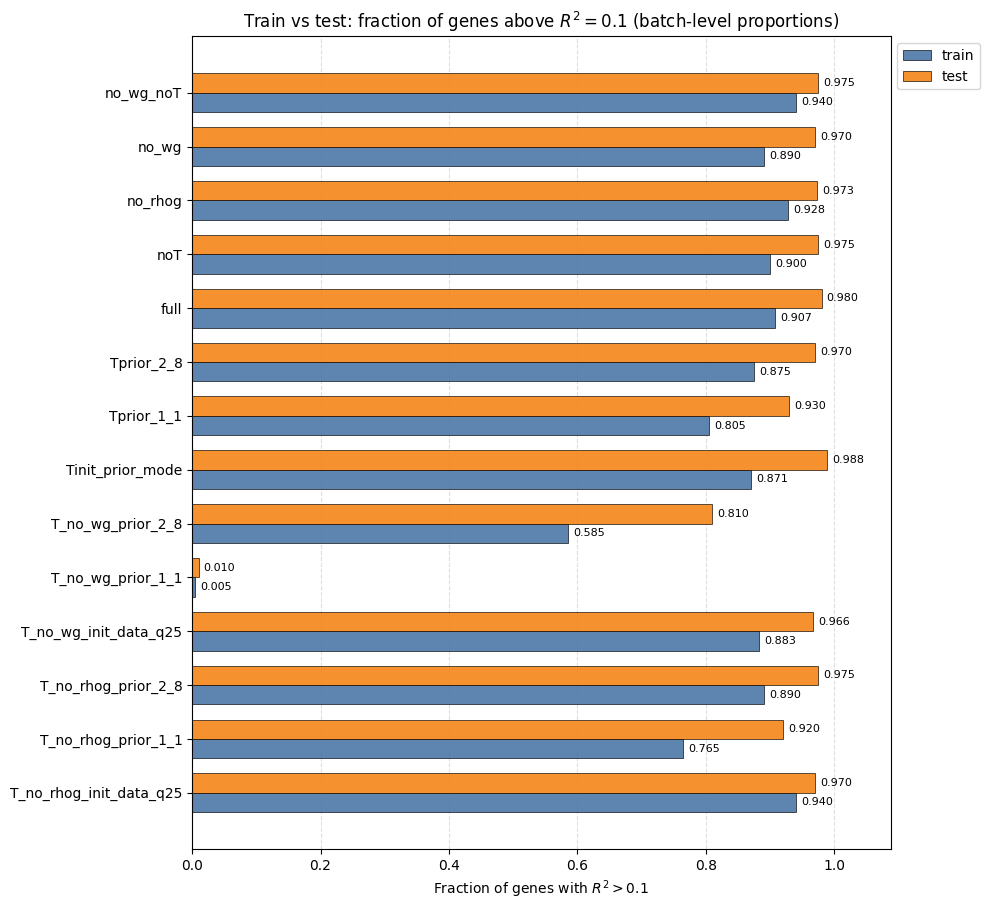

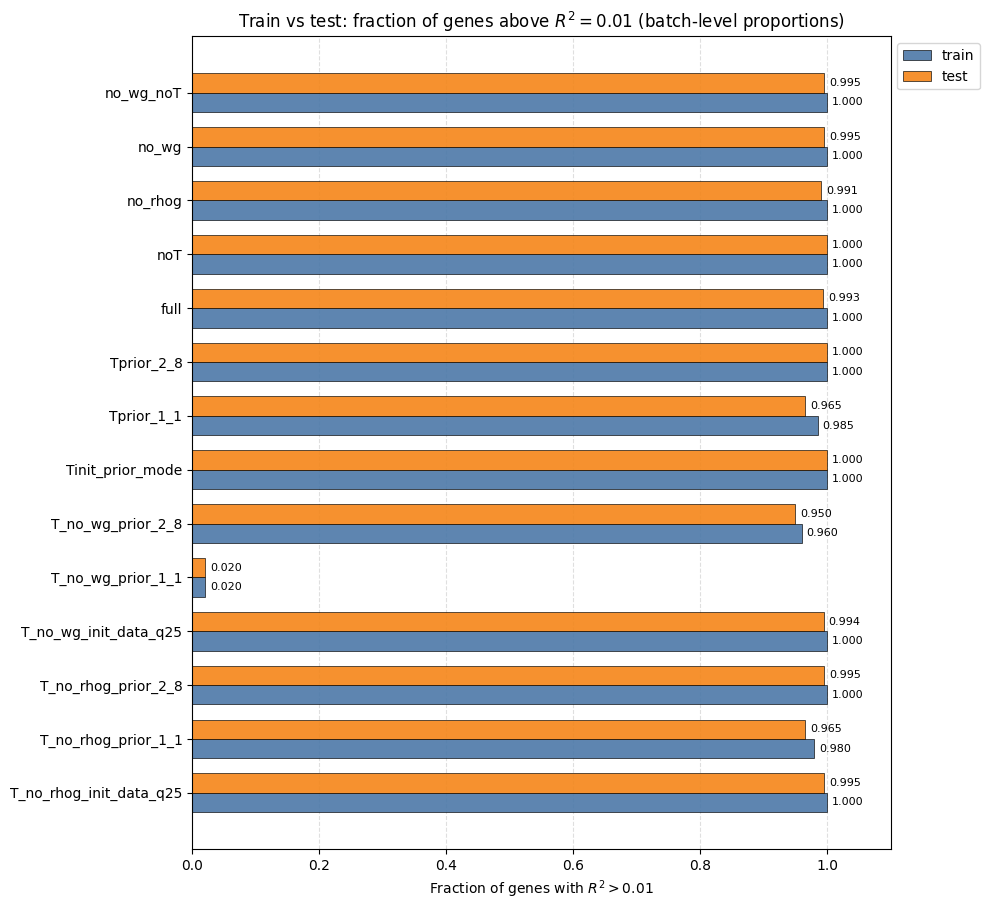

In [9]:
# Optional: top-200 BRR genes (same gene set as joint plots when top-200 BRR genes used for joint)
TOP200_GENES_PATH = (
    "/gpfs/commons/home/vmazeeva/firvTWAS/emmental/src/genes/top200_BRR_genes.txt"
)
batch_df_pergene_top200 = r2.get_r2_stats_batched_pergene(experiments_pergene, BATCH_SIZE, gene_list_path=TOP200_GENES_PATH)
r2.plot_train_test_bars(batch_df_pergene_top200, thresh=0.1)
r2.plot_train_test_bars(batch_df_pergene_top200, thresh=0.01)




# Emmental vs baselines (R² proportions + means)

In [72]:
import importlib
importlib.reload(r2)

<module 'r2' from '/gpfs/commons/home/vmazeeva/firvTWAS/emmental/plotting/r2.py'>

In [2]:
MYOUT = "/gpfs/commons/home/vmazeeva/firvTWAS_myout"
EXP = "train_common01_normG_collapse"
post_dir = f"{MYOUT}/{EXP}/post_pergene"

try:
    display
except NameError:
    from IPython.display import display

#### Pergene emmental fit vs baselines (i.e. Emmental common-only vs baseline common-only)


=== train_common01_normG_collapse | pergene fit | n_genes=16220 ===
emmental: /gpfs/commons/home/vmazeeva/firvTWAS_myout/train_common01_normG_collapse/pergene
baseline: /gpfs/commons/home/adas/uTWAS/src/results/baseline_full_common01
r2_col: r2


threshold          0.00          0.01          0.10       
split              test  train   test  train   test  train
method                                                    
Bayesian Ridge    0.567  1.000  0.234  0.818  0.022  0.044
Elastic Net       0.560  0.898  0.216  0.621  0.022  0.040
Emmental pergene  0.606  1.000  0.259  0.948  0.022  0.039
Lasso             0.562  0.896  0.216  0.616  0.022  0.039
Ridge             0.544  1.000  0.240  0.935  0.023  0.038

split,test,train
method,,
Bayesian Ridge,0.0055,0.0349
Elastic Net,0.0059,0.0278
Emmental pergene,0.0071,0.0366
Lasso,0.0060,0.0273
Ridge,0.0047,0.0370


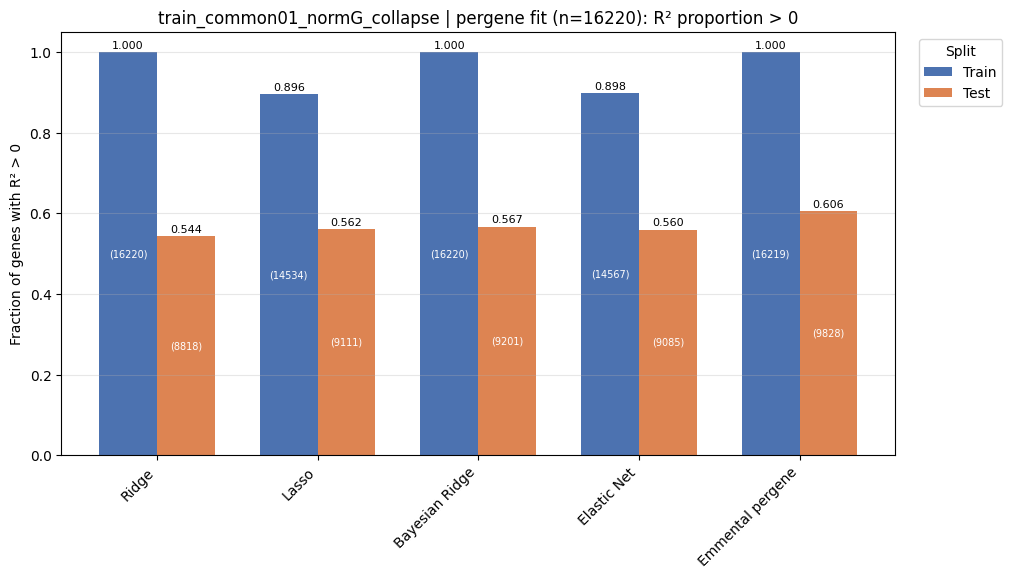

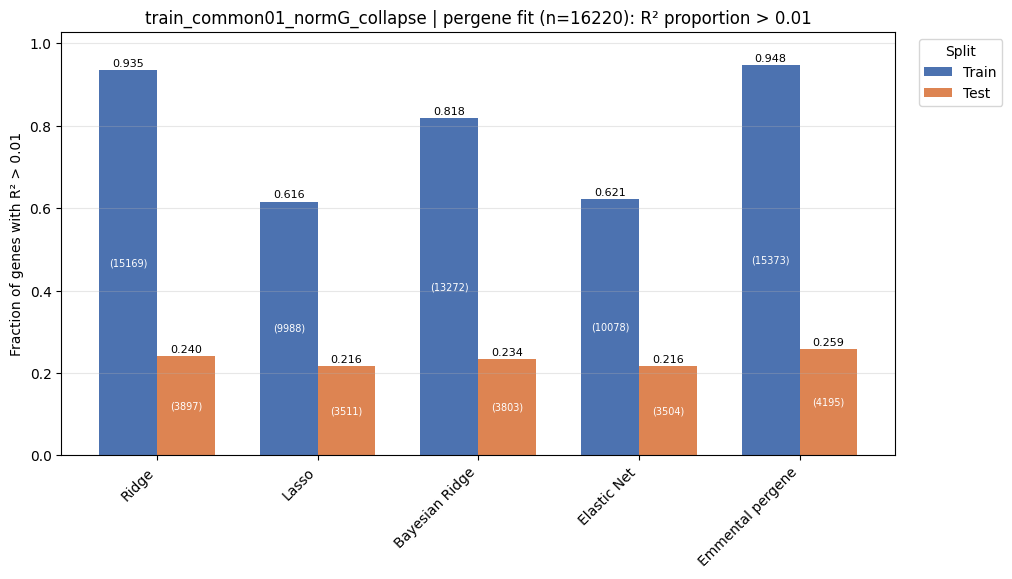

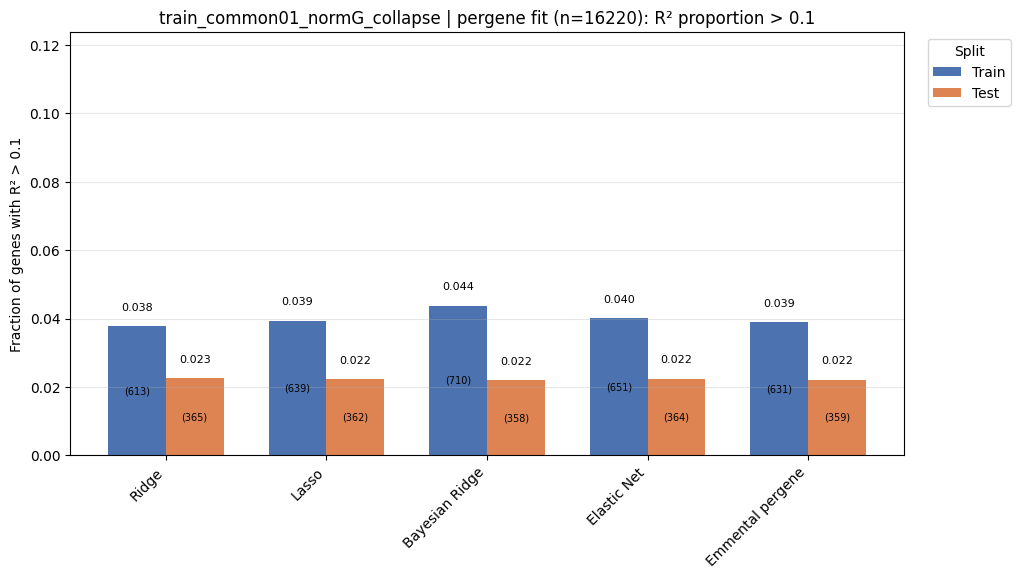

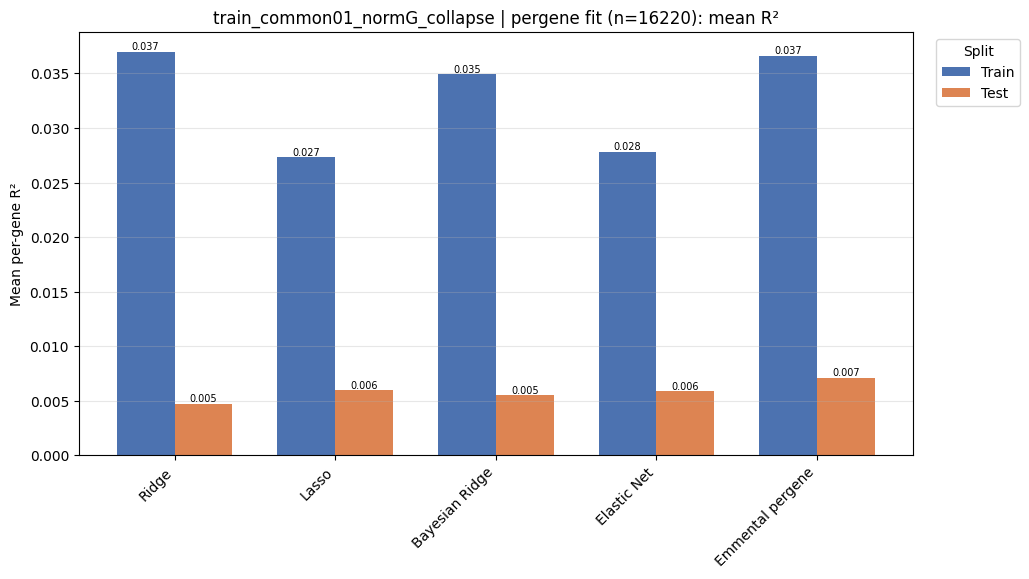

In [70]:
# --- Pergene training R² vs same baseline ---
prep_pergene = r2.prep_pergene_vs_baseline(
    f"{MYOUT}/{EXP}",
    title=f"{EXP} | pergene fit",
    display_stats_table=True,
)
r2.plot_vs_baseline(prep_pergene)

#### Explore $\beta$ sources
Post-train R² columns: `r2_common_only__c_{common}` and `r2_common_plus_rare__c_{common}__r_{rare}`.


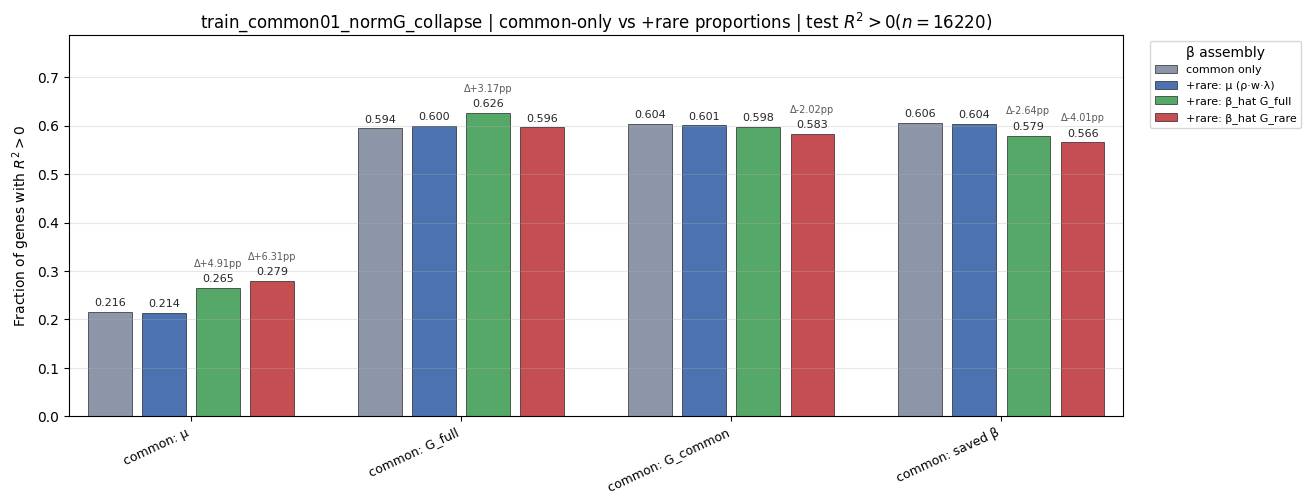

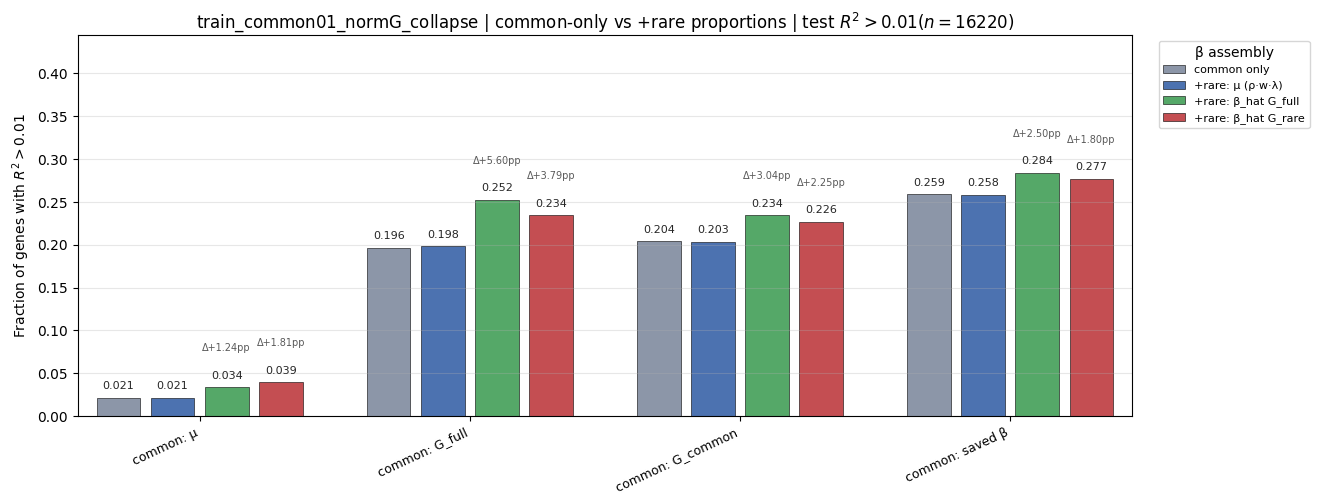

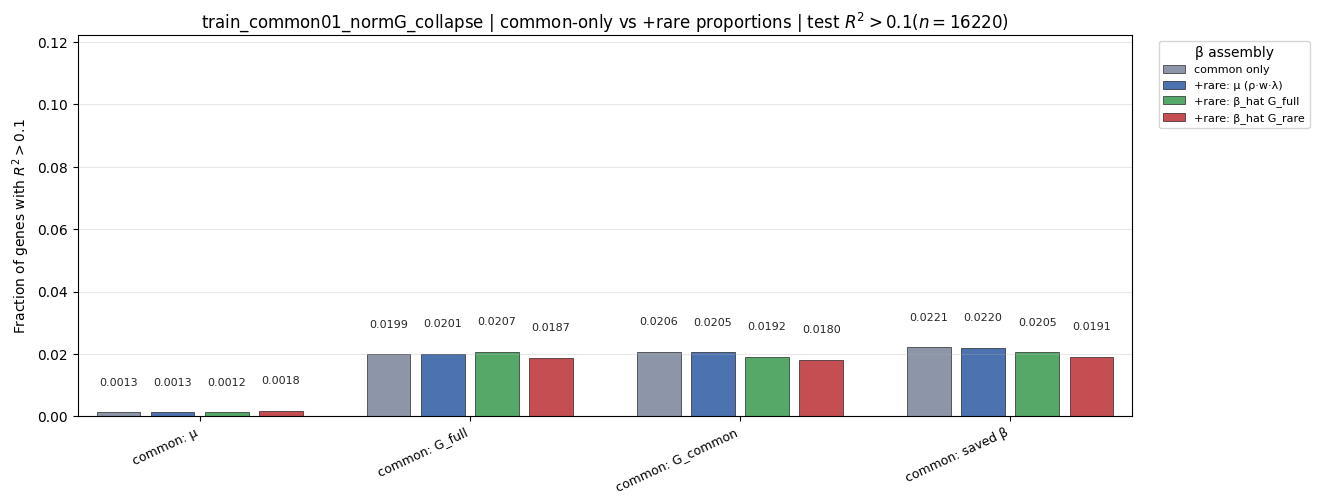

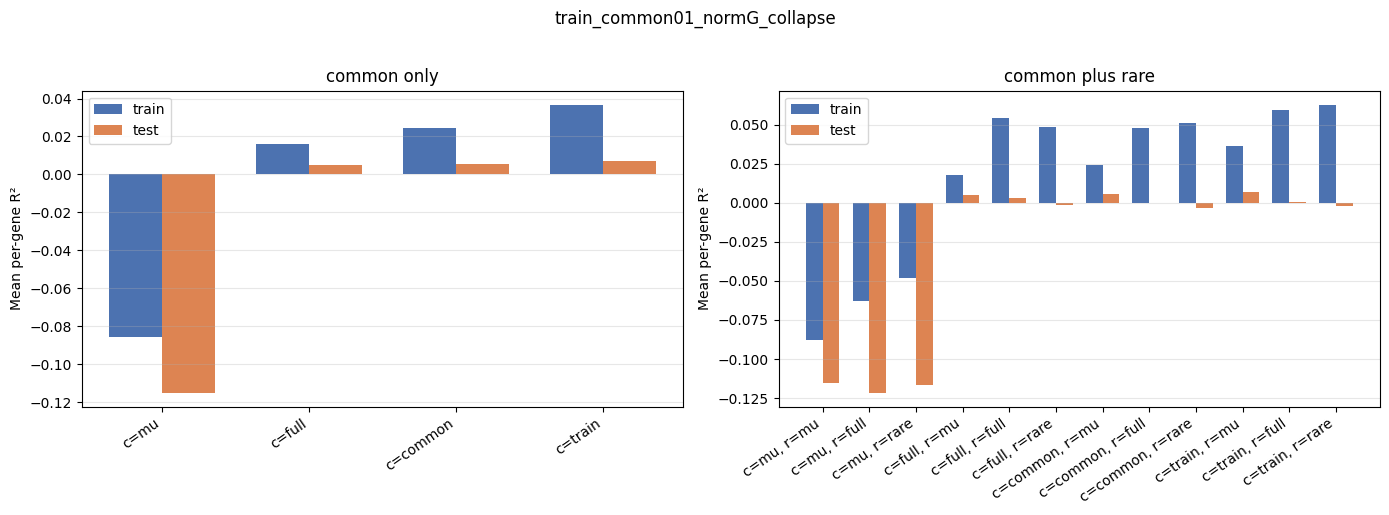

In [73]:
source_cmp = r2.compare_post_train_r2_sources(post_dir)

panel_table = r2.plot_post_train_r2_panel_proportions(
    source_cmp["summary"],
    title=f"{EXP} | common-only vs +rare proportions",
    show_delta=True, delta_min_pp=1.0,
)

r2.plot_post_train_r2_sources(source_cmp["summary"], title=EXP)



#### Baselines vs Emmental common, common+rare

In [27]:
import importlib
importlib.reload(r2)

<module 'r2' from '/gpfs/commons/home/vmazeeva/firvTWAS/emmental/plotting/r2.py'>

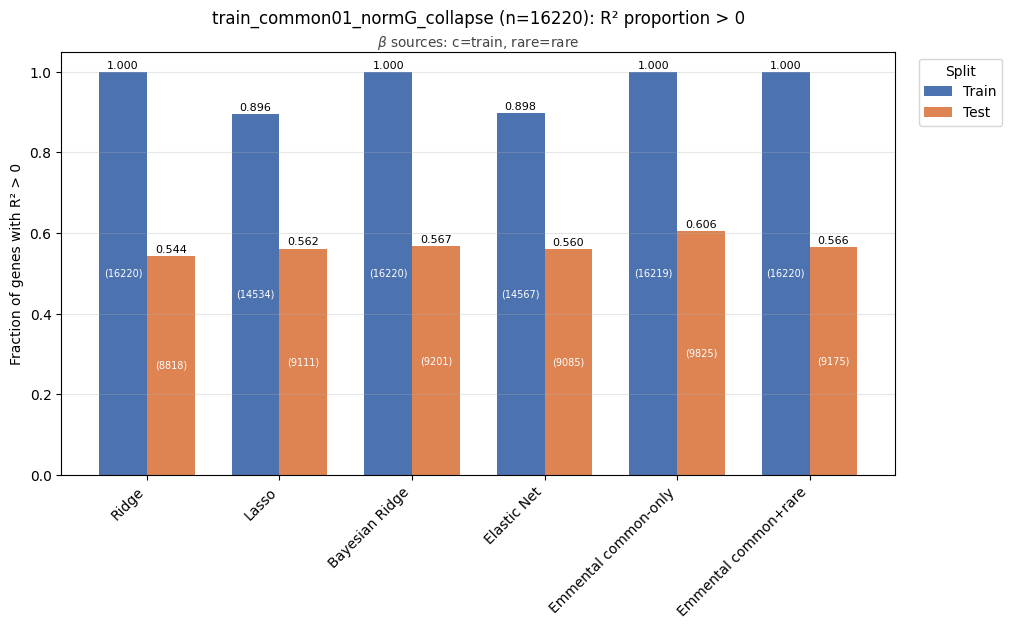

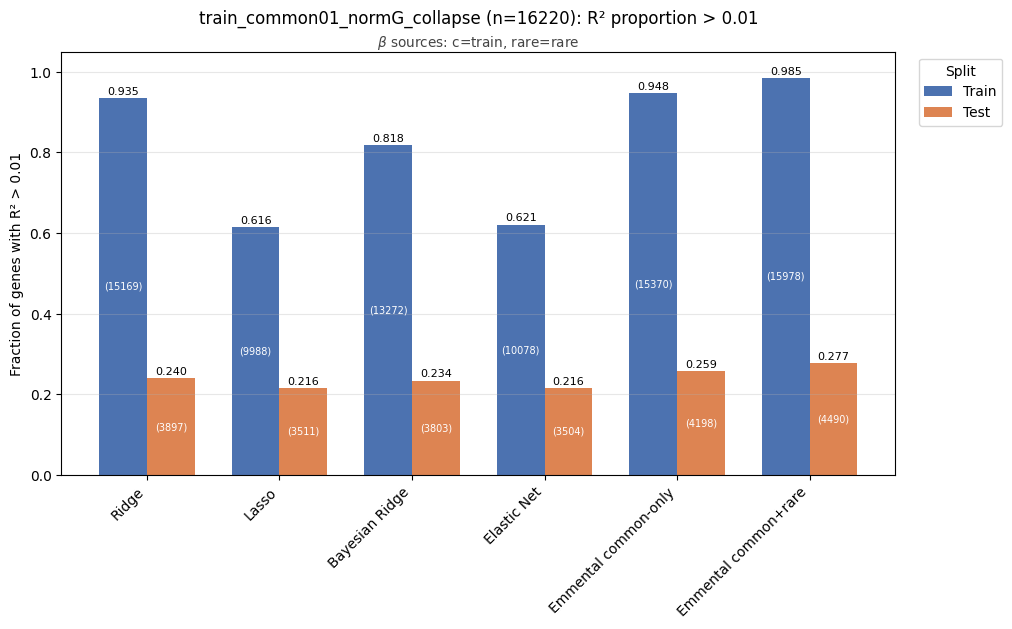

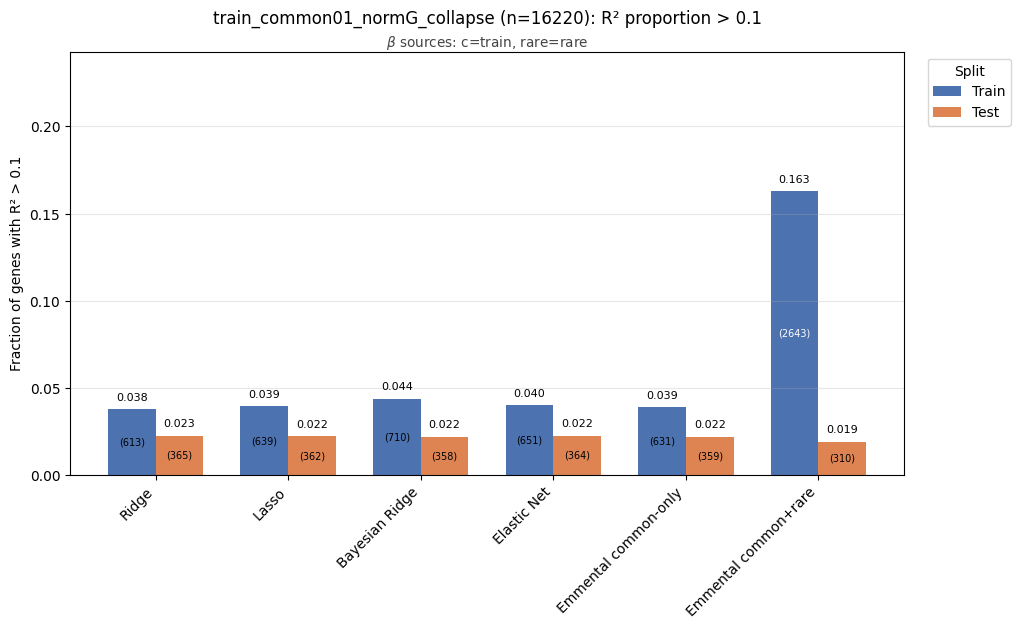

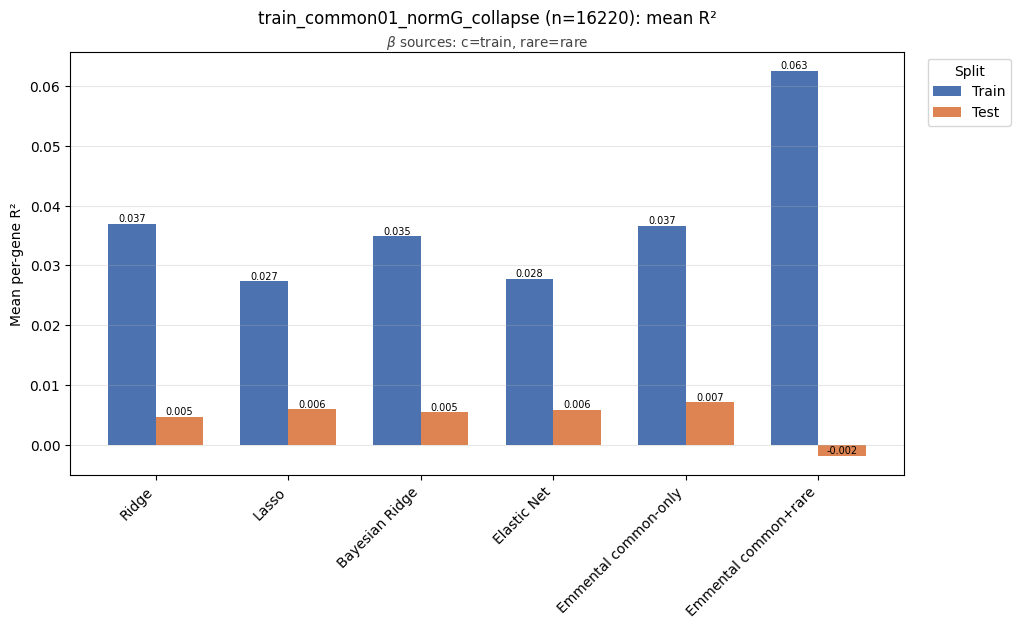

In [28]:
# --- Post-train vs baseline_full_common01 ---
COMMON_BETA = "train"  # mu | full | common | train
RARE_BETA = "rare"      # None -> common-only only; else also +rare bar

prep_post = r2.prep_emmental_vs_baseline(
    post_dir,
    common_beta=COMMON_BETA,
    rare_beta=RARE_BETA,
    title=f"{EXP}",
    display_stats_table=False,
)
r2.plot_vs_baseline(prep_post)


#### Top-gene overlap: Emmental vs baselines

In [10]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module=r"upsetplot(\.|$)",
)

In [29]:
# Default assemblies: (common, None) baseline-fair + (common, rare) full panel.

OVERLAP_COMMON_BETA = "train"  # mu | full | common | train
OVERLAP_RARE_BETA = "full"      # None -> common-only only

overlap = r2.prep_gene_overlap_vs_baseline(
    post_dir,
    label=EXP,
    common_beta=OVERLAP_COMMON_BETA,
    rare_beta=OVERLAP_RARE_BETA,
    split="test"
)


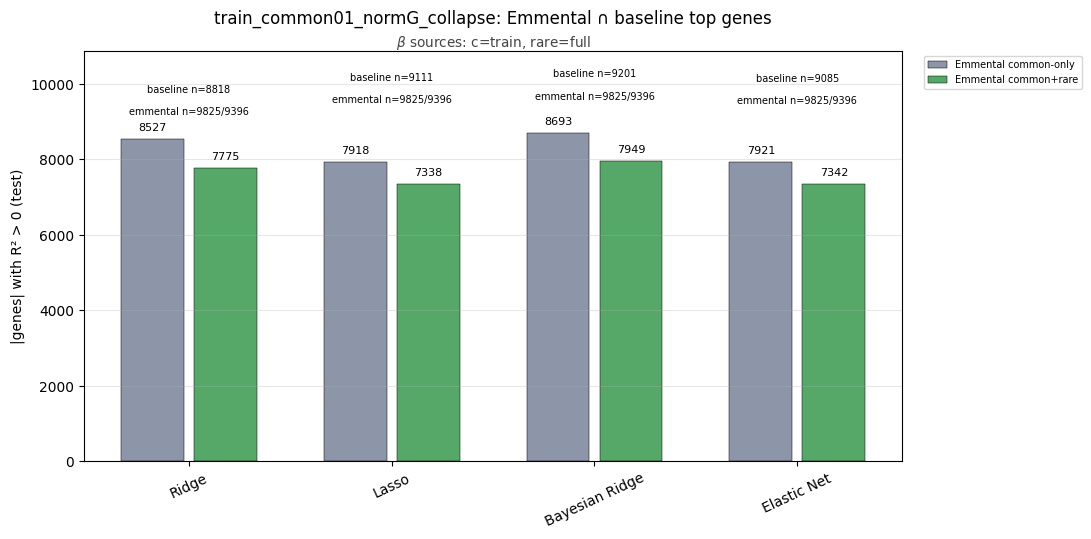

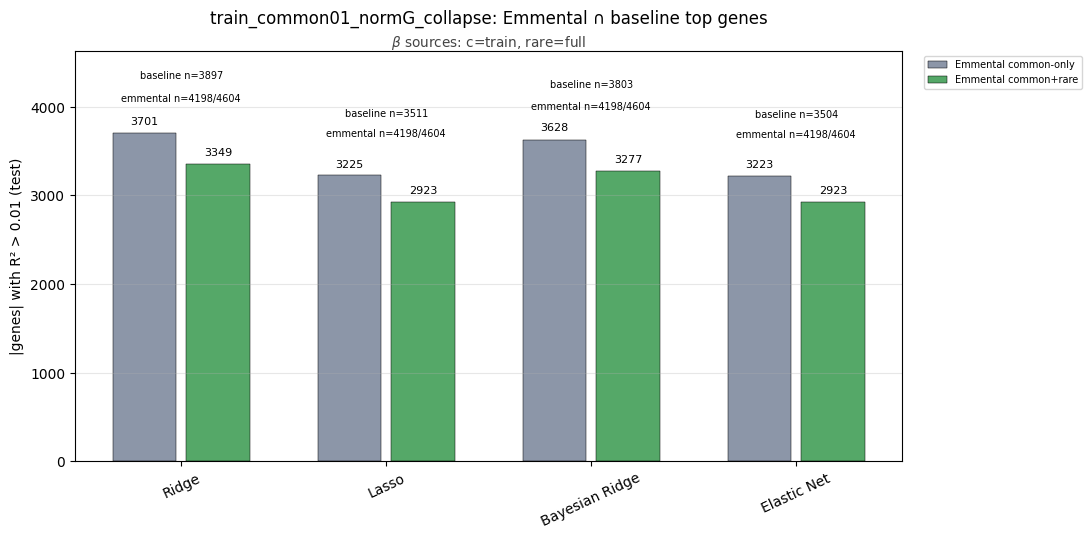

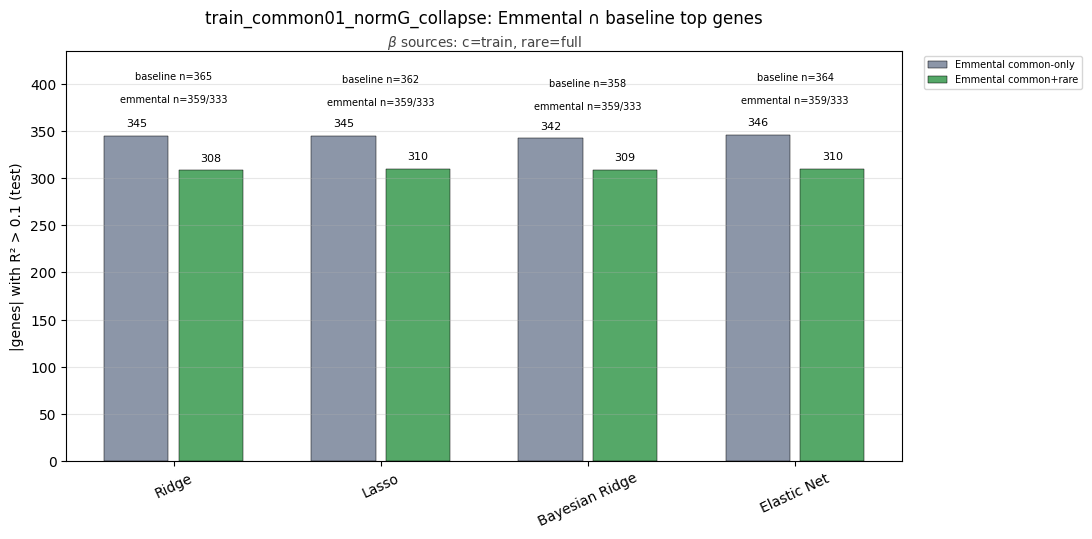

In [31]:
r2.plot_gene_overlap_intersection_bars(overlap)

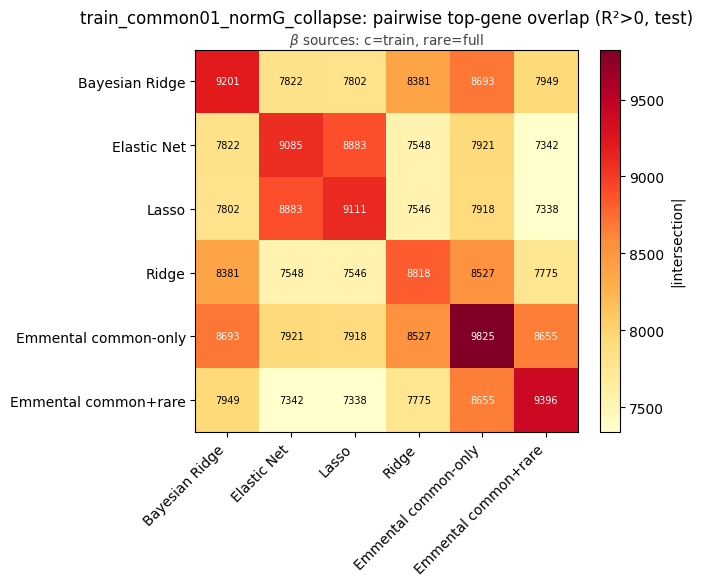

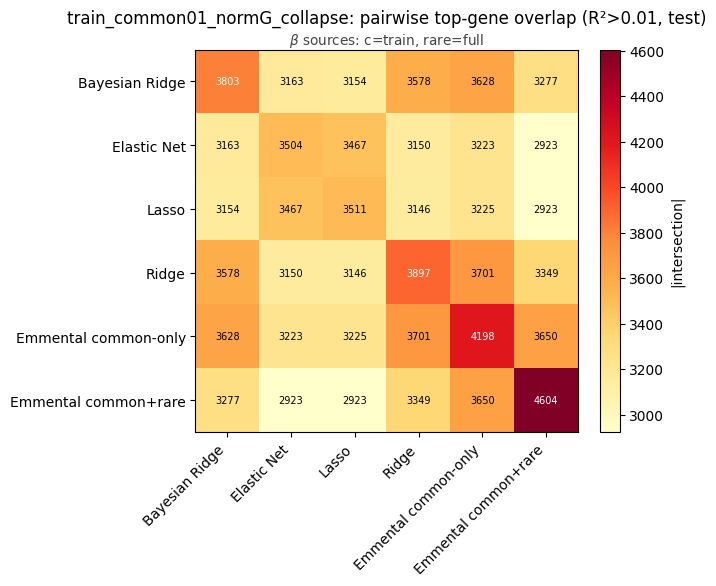

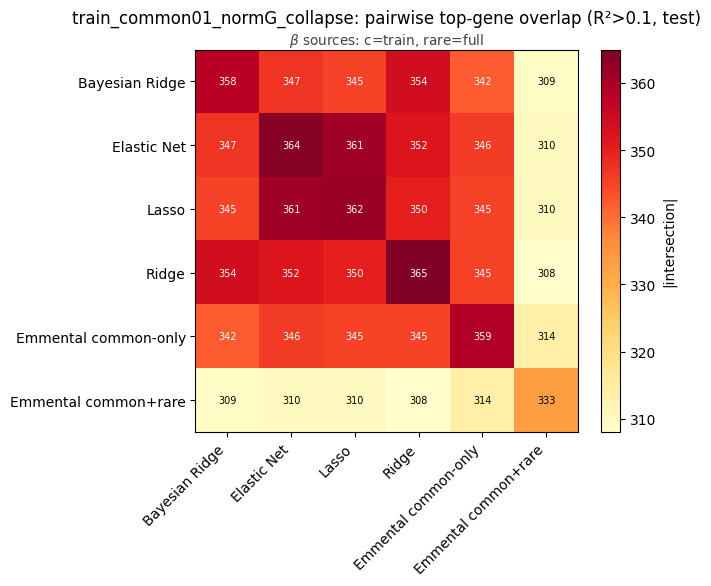

In [32]:
r2.plot_gene_overlap_heatmaps(overlap)


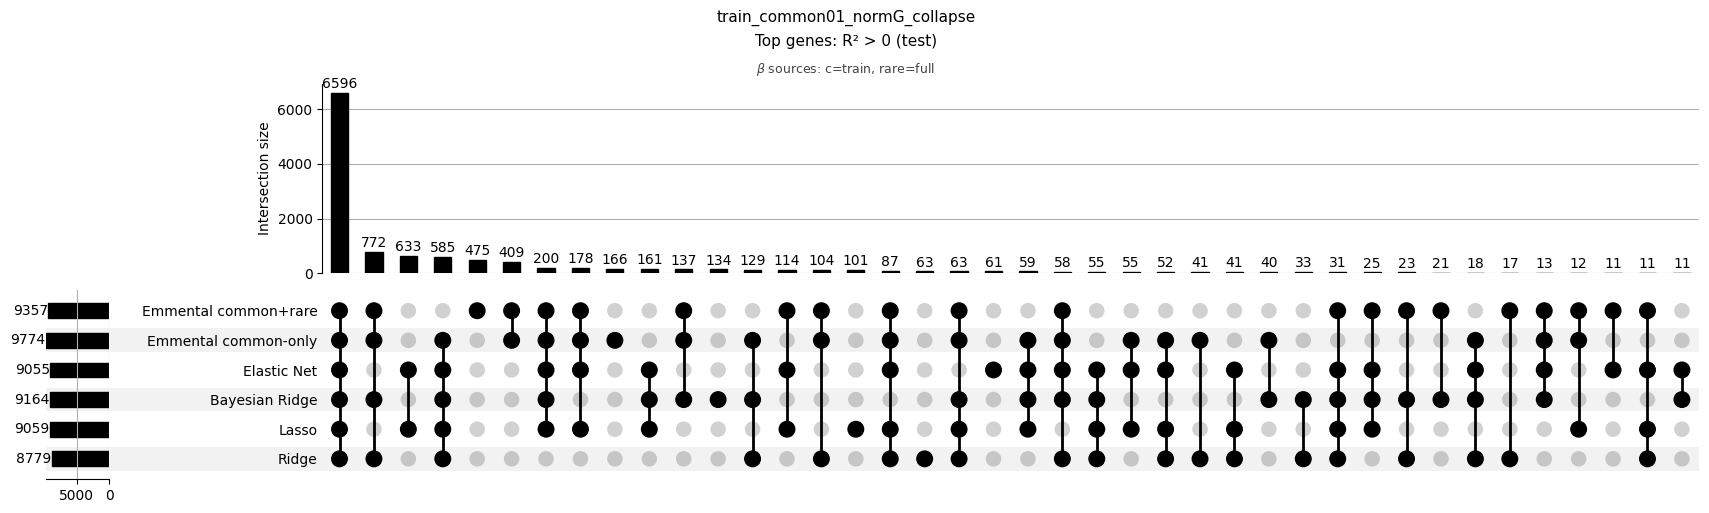

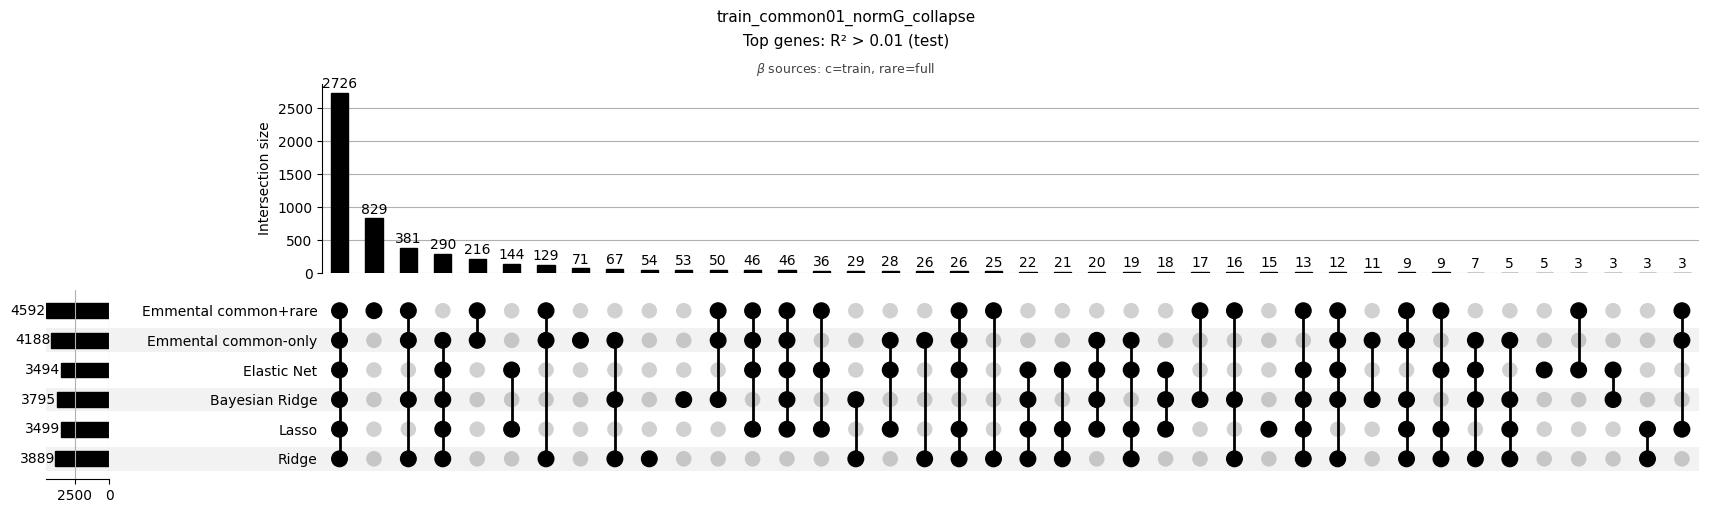

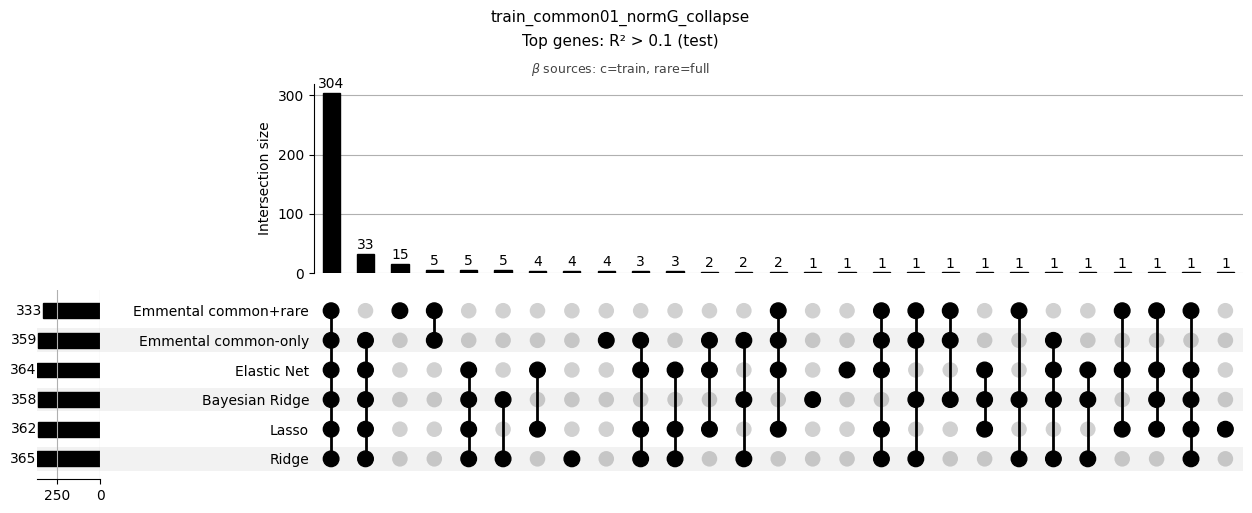

In [33]:
upset_tables = r2.plot_gene_overlap_upsets(
    overlap,
    upset_modes=("all",),  # "all", "common_only", "common_plus_rare", or r2.UPSET_OVERLAP_MODES
)

# Overall R² (common vs +rare)

In [ ]:
import matplotlib.pyplot as plt
import r2

In [4]:
MYOUT = "/gpfs/commons/home/vmazeeva/firvTWAS_myout"
EXP = "train_common01_normG_collapse"  
post_dir = f"{MYOUT}/{EXP}/post_pergene"

COMMON_BETA = "train"   
RARE_BETA = "full"
SPLIT = "test"
THRESHOLD = 0.01

## 1. Mean / median ΔR² across genes

In [7]:
long_df, _ = r2.load_post_train_r2_long_multi(
    post_dir,
    [(COMMON_BETA, None), (COMMON_BETA, RARE_BETA)],
)
m_co = r2.emmental_model_key(COMMON_BETA, None)
m_cr = r2.emmental_model_key(COMMON_BETA, RARE_BETA)
co = long_df.loc[long_df["model"] == m_co, ["gene", "ensg", "R2_test"]].rename(
    columns={"R2_test": "r2_common_only"}
)
cr = long_df.loc[long_df["model"] == m_cr, ["gene", "ensg", "R2_test"]].rename(
    columns={"R2_test": "r2_common_plus_rare"}
)
delta_df = co.merge(cr, on=["gene", "ensg"], how="inner")
delta_df["r2_delta"] = (
    delta_df["r2_common_plus_rare"].astype(float)
    - delta_df["r2_common_only"].astype(float)
)
print(f"Total genes: {len(delta_df)}")
print(f"Mean ΔR²:   {delta_df['r2_delta'].mean():.4f}")
print(f"Median ΔR²: {delta_df['r2_delta'].median():.4f}")
print(f"Frac ΔR² > 0: {(delta_df['r2_delta'] > 0).mean():.1%}")
print(f"Frac ΔR² < 0: {(delta_df['r2_delta'] < 0).mean():.1%}")


Total genes: 16220
Mean ΔR²:   -0.0064
Median ΔR²: -0.0001
Frac ΔR² > 0: 47.6%
Frac ΔR² < 0: 52.4%


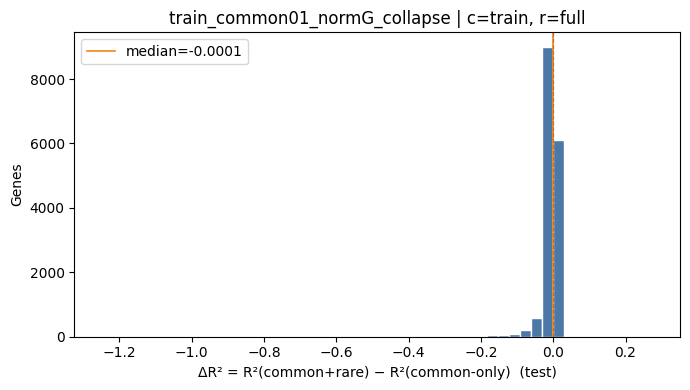

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(delta_df["r2_delta"].dropna(), bins=50, color="#4c78a8", edgecolor="white")
ax.axvline(0, color="black", ls="--", lw=0.8)
ax.axvline(delta_df["r2_delta"].median(), color="#f58518", lw=1.2,
           label=f"median={delta_df['r2_delta'].median():.4f}")
ax.set_xlabel(f"ΔR² = R²(common+rare) − R²(common-only)  ({SPLIT})")
ax.set_ylabel("Genes")
ax.set_title(f"{EXP} | c={COMMON_BETA}, r={RARE_BETA}")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Rare gain genes (cross threshold only with rare)

====== Threshold: 0.01 ======
Rare gain genes (R² (common) < 0.01 → R² (common+rare) > 0.01): 954
Mean ΔR²:   0.0092
Median ΔR²: 0.0076



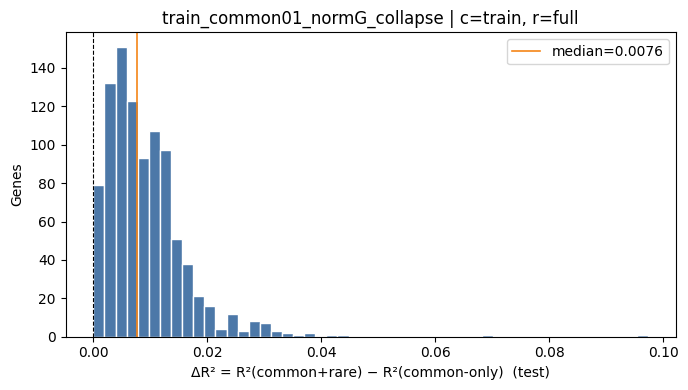

====== Threshold: 0.1 ======
Rare gain genes (R² (common) < 0.1 → R² (common+rare) > 0.1): 19
Mean ΔR²:   0.0607
Median ΔR²: 0.0171



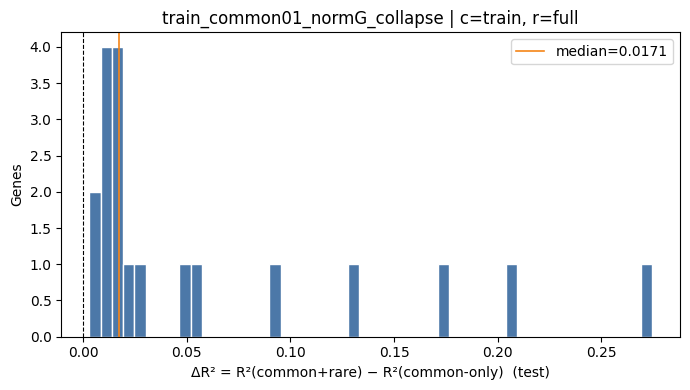

In [13]:
# Load per-gene R² for both assemblies
for thr in [0.01, 0.1]:
    gain_df = r2.emmental_rare_gain_genes(
        post_dir,
        common_beta=COMMON_BETA,
        rare_beta=RARE_BETA,
        threshold=thr,         
        split=SPLIT,
    )
    print(f"====== Threshold: {thr} ======")
    print(f"Rare gain genes (R² (common) < {thr} → R² (common+rare) > {thr}): {len(gain_df)}")
    print(f"Mean ΔR²:   {gain_df['r2_delta'].mean():.4f}")
    print(f"Median ΔR²: {gain_df['r2_delta'].median():.4f}\n")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(gain_df["r2_delta"].dropna(), bins=50, color="#4c78a8", edgecolor="white")
    ax.axvline(0, color="black", ls="--", lw=0.8)
    ax.axvline(gain_df["r2_delta"].median(), color="#f58518", lw=1.2,
            label=f"median={gain_df['r2_delta'].median():.4f}")
    ax.set_xlabel(f"ΔR² = R²(common+rare) − R²(common-only)  ({SPLIT})")
    ax.set_ylabel("Genes")
    ax.set_title(f"{EXP} | c={COMMON_BETA}, r={RARE_BETA}")
    ax.legend()
    plt.tight_layout()
    plt.show()